# Multi-Channel Attribution Analysis - Visualization
## RQ1, RQ2, RQ3 Charts

This notebook generates comprehensive visualizations for the multi-touch attribution analysis project, including attribution comparisons, channel performance metrics, and budget simulation outcomes.

## 1. Import Required Libraries

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style and figure size defaults
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Attribution Data Files

In [57]:
# Define base paths
base_path = './outputs/'
rq1_basic = base_path + 'rq1_basic/'
rq2_logit = base_path + 'rq2_logit/'
rq2_markov = base_path + 'rq2_markov/'
rq3_simulation = base_path + 'rq3_simulation/'

# Load data files
df_attribution_share = pd.read_csv(rq1_basic + '01_attribution_share.csv', index_col=0)
df_conversion_rate = pd.read_csv(rq1_basic + '01_channel_conversion_rate.csv')
df_logit_adjusted = pd.read_csv(rq2_logit + '02_adjusted_channel_share.csv', index_col=0)
df_model_comparison = pd.read_csv(rq2_markov + '03_model_comparison.csv', index_col=0)
df_removal_effect = pd.read_csv(rq2_markov + '03_removal_effect.csv', index_col=0)
df_simulation = pd.read_csv(rq3_simulation + '04_results.csv')

print("Data Shapes:")
print(f"Attribution Share: {df_attribution_share.shape}")
print(f"Conversion Rate: {df_conversion_rate.shape}")
print(f"Logit Adjusted: {df_logit_adjusted.shape}")
print(f"Model Comparison: {df_model_comparison.shape}")
print(f"Removal Effect: {df_removal_effect.shape}")
print(f"Simulation: {df_simulation.shape}")
print("\nAll data files loaded successfully!")

Data Shapes:
Attribution Share: (6, 3)
Conversion Rate: (6, 5)
Logit Adjusted: (6, 1)
Model Comparison: (6, 5)
Removal Effect: (6, 6)
Simulation: (3, 7)

All data files loaded successfully!


## 3. RQ1: Attribution Share by Method (Grouped Bar Chart)

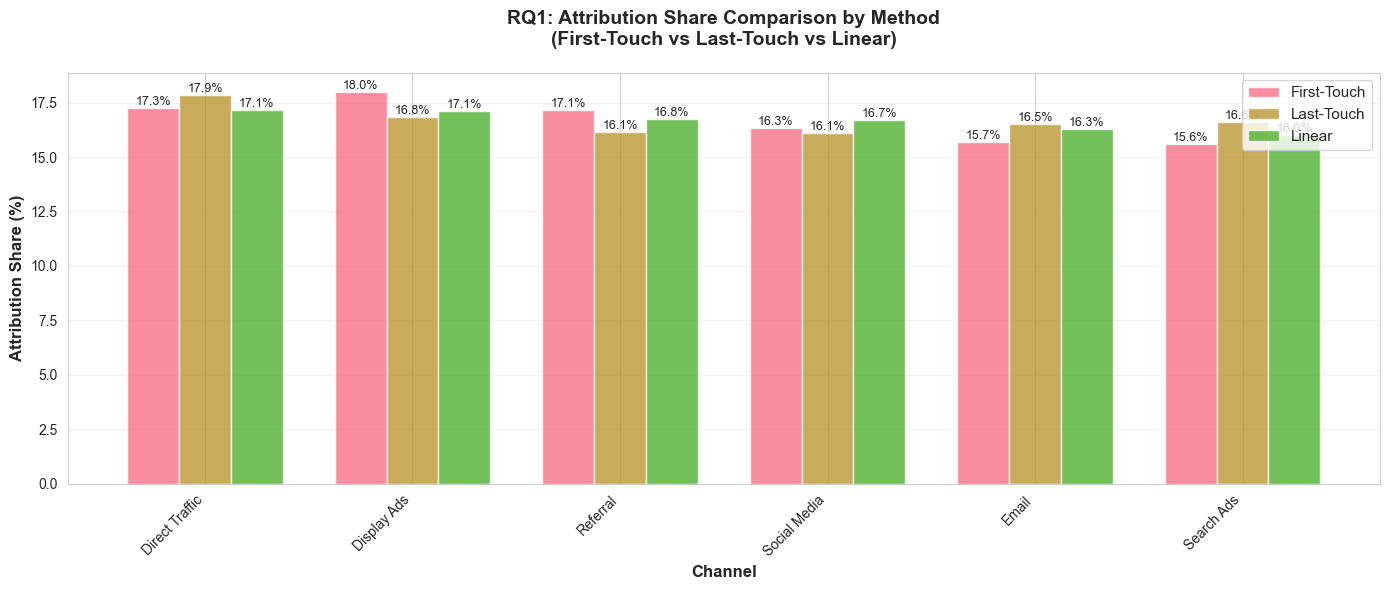

Chart 1 saved: Attribution Share by Method


In [58]:
fig, ax = plt.subplots(figsize=(14, 6))

# Prepare data
x = np.arange(len(df_attribution_share.index))
width = 0.25

# Plot bars
bars1 = ax.bar(x - width, df_attribution_share['first_touch_pct'], width, label='First-Touch', alpha=0.8)
bars2 = ax.bar(x, df_attribution_share['last_touch_pct'], width, label='Last-Touch', alpha=0.8)
bars3 = ax.bar(x + width, df_attribution_share['linear_pct'], width, label='Linear', alpha=0.8)

# Customize
ax.set_xlabel('Channel', fontsize=12, fontweight='bold')
ax.set_ylabel('Attribution Share (%)', fontsize=12, fontweight='bold')
ax.set_title('RQ1: Attribution Share Comparison by Method\n(First-Touch vs Last-Touch vs Linear)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(df_attribution_share.index, rotation=45, ha='right')
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(rq1_basic + 'chart_01_attribution_share_by_method.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart 1 saved: Attribution Share by Method")

## 4. RQ1: Channel Conversion Rate (Horizontal Bar Chart)

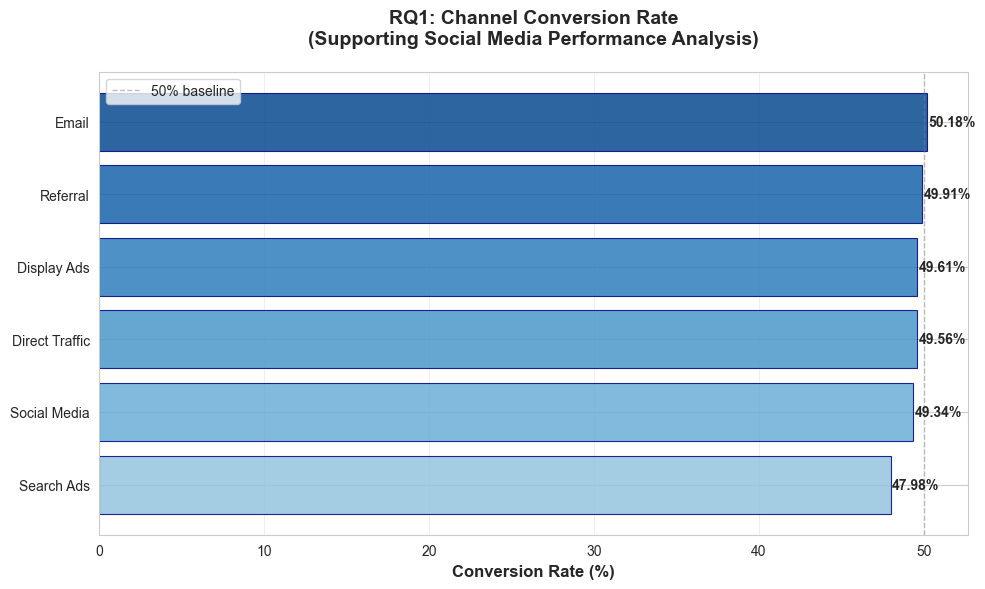

Chart 2 saved: Channel Conversion Rate


In [59]:
# Sort by conversion rate
df_conv_sorted = df_conversion_rate.sort_values('conversion_rate_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

# Create gradient colors based on conversion rate values
colors_gradient = plt.cm.Blues(np.linspace(0.4, 0.9, len(df_conv_sorted)))

bars = ax.barh(df_conv_sorted['Channel'], df_conv_sorted['conversion_rate_pct'], 
               color=colors_gradient, alpha=0.85, edgecolor='navy', linewidth=0.8)

# Customize
ax.set_xlabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('RQ1: Channel Conversion Rate\n(Supporting Social Media Performance Analysis)', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(df_conv_sorted.iterrows()):
    ax.text(row['conversion_rate_pct'] + 0.1, i, f"{row['conversion_rate_pct']:.2f}%", 
            va='center', fontsize=10, fontweight='bold')

# Add reference lines
ax.axvline(x=50.0, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='50% baseline')
ax.legend()

plt.tight_layout()
plt.savefig(rq1_basic + 'chart_02_channel_conversion_rate.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart 2 saved: Channel Conversion Rate")

## 5. RQ2: Logit-Adjusted Attribution Share (Bar Chart)

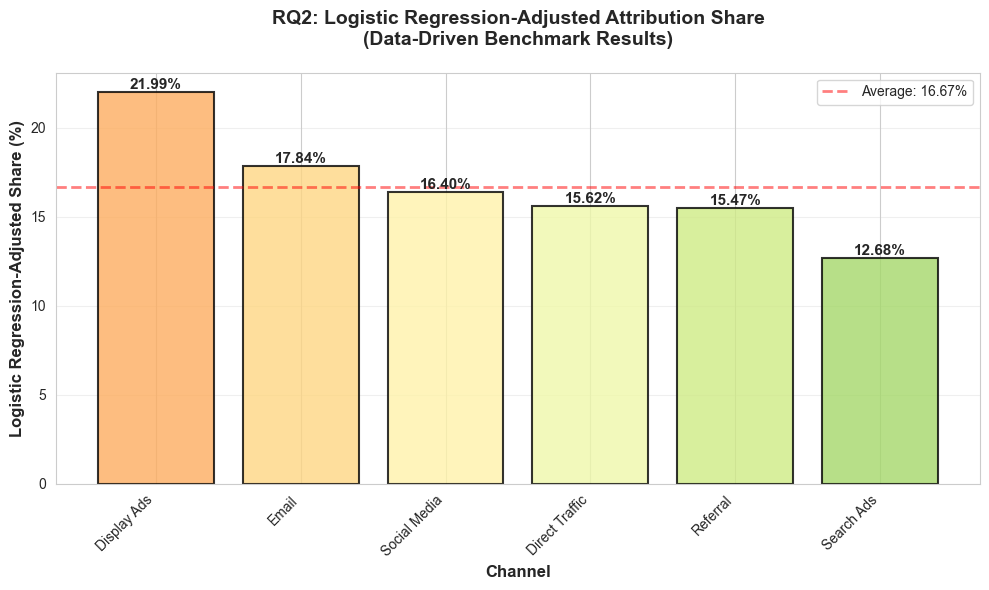

Chart 3 saved: Logit-Adjusted Attribution Share


In [60]:
# Sort by logit adjusted share
df_logit_sorted = df_logit_adjusted.sort_values('logit_adjusted_share_pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.RdYlGn(np.linspace(0.3, 0.7, len(df_logit_sorted)))
bars = ax.bar(range(len(df_logit_sorted)), df_logit_sorted['logit_adjusted_share_pct'], 
              color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Customize
ax.set_xlabel('Channel', fontsize=12, fontweight='bold')
ax.set_ylabel('Logistic Regression-Adjusted Share (%)', fontsize=12, fontweight='bold')
ax.set_title('RQ2: Logistic Regression-Adjusted Attribution Share\n(Data-Driven Benchmark Results)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(range(len(df_logit_sorted)))
ax.set_xticklabels(df_logit_sorted.index, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add average line
avg_share = df_logit_sorted['logit_adjusted_share_pct'].mean()
ax.axhline(y=avg_share, color='red', linestyle='--', alpha=0.5, linewidth=2, label=f'Average: {avg_share:.2f}%')
ax.legend()

plt.tight_layout()
plt.savefig(rq2_logit + 'chart_03_logit_adjusted_share.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart 3 saved: Logit-Adjusted Attribution Share")

## 6. RQ2: Model Comparison Across Attribution Methods (Heatmap)

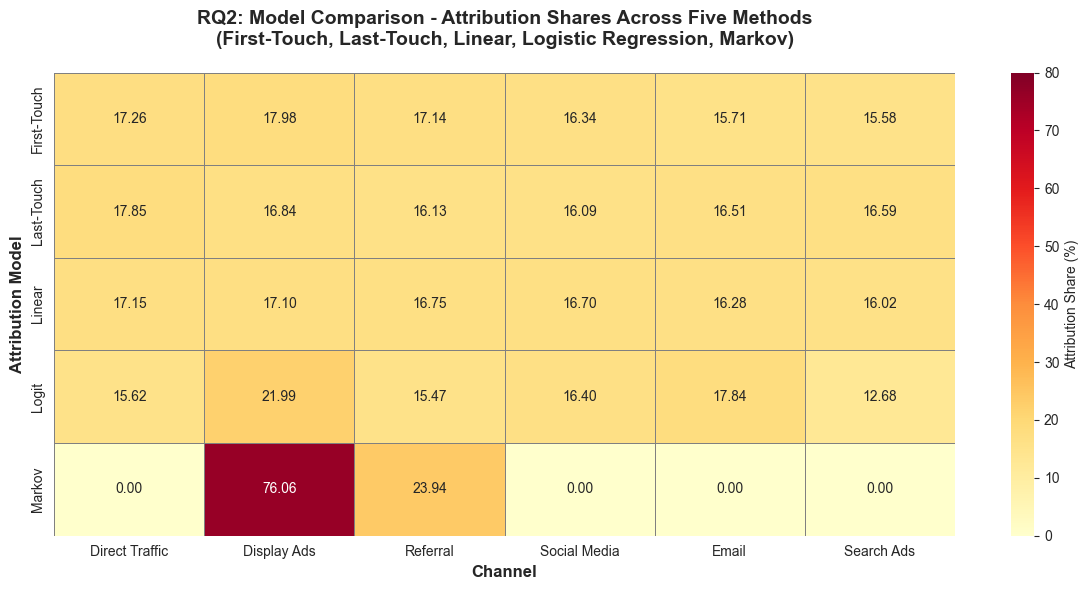

Chart 4 saved: Model Comparison Heatmap


In [61]:
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare heatmap data
heatmap_data = df_model_comparison[['first_touch_pct', 'last_touch_pct', 'linear_pct', 
                                     'logit_adjusted_pct', 'markov_positive_removal_pct']]
heatmap_data.columns = ['First-Touch', 'Last-Touch', 'Linear', 'Logit', 'Markov']

# Create heatmap
sns.heatmap(heatmap_data.T, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Attribution Share (%)'}, 
            linewidths=0.5, linecolor='gray', ax=ax, vmin=0, vmax=80)

ax.set_ylabel('Attribution Model', fontsize=12, fontweight='bold')
ax.set_xlabel('Channel', fontsize=12, fontweight='bold')
ax.set_title('RQ2: Model Comparison - Attribution Shares Across Five Methods\n(First-Touch, Last-Touch, Linear, Logistic Regression, Markov)', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(rq2_markov + 'chart_04_model_comparison_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart 4 saved: Model Comparison Heatmap")

## 7. RQ2: Markov Removal Effect (Horizontal Bar Chart)

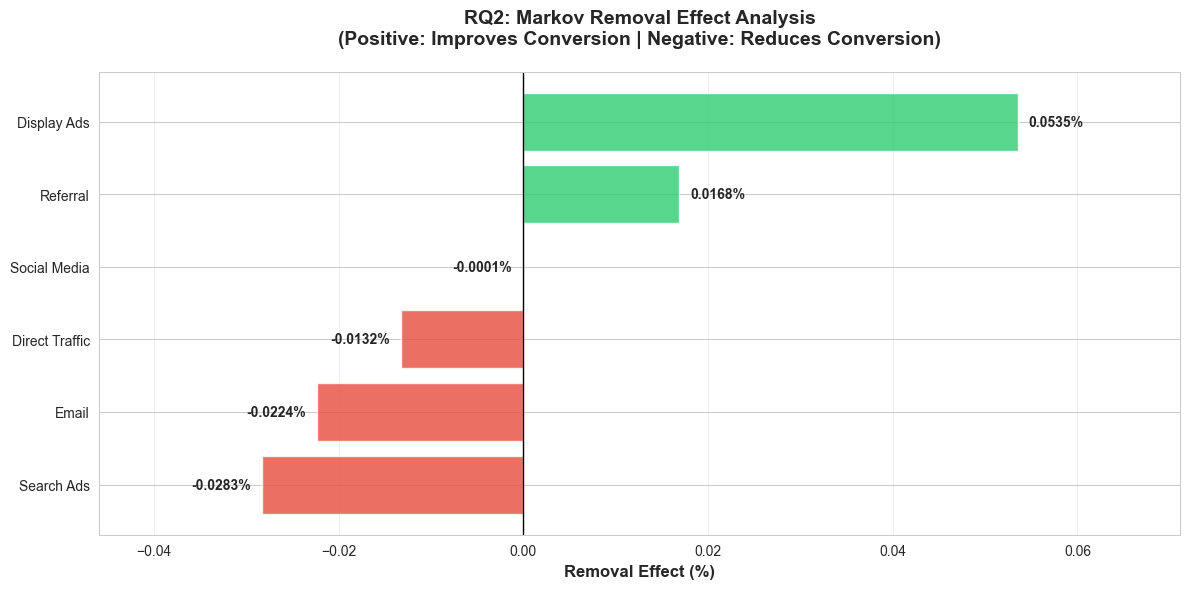

Chart 5 saved: Markov Removal Effect


In [62]:
# Sort by removal effect
df_removal_sorted = df_removal_effect.sort_values('removal_effect_pct', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))

# Create colors - highlight channels with positive removal effect
colors = ['#2ecc71' if val > 0 else '#e74c3c' for val in df_removal_sorted['removal_effect_pct']]

bars = ax.barh(df_removal_sorted.index, df_removal_sorted['removal_effect_pct'], color=colors, alpha=0.8)

# Customize
ax.set_xlabel('Removal Effect (%)', fontsize=12, fontweight='bold')
ax.set_title('RQ2: Markov Removal Effect Analysis\n(Positive: Improves Conversion | Negative: Reduces Conversion)', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)
ax.axvline(x=0, color='black', linewidth=1)

# Add value labels using bar_label for automatic styling and padding
ax.bar_label(bars, fmt='%.4f%%', padding=8, fontsize=10, fontweight='bold')

# Adjust x-axis limits to provide more space for labels (15% padding on each side)
x_min, x_max = ax.get_xlim()
x_range = x_max - x_min
ax.set_xlim(x_min - x_range * 0.15, x_max + x_range * 0.15)

plt.tight_layout()
plt.savefig(rq2_markov + 'chart_05_markov_removal_effect.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart 5 saved: Markov Removal Effect")

## 8. RQ3: Simulation Scenario Results (Bar Chart)

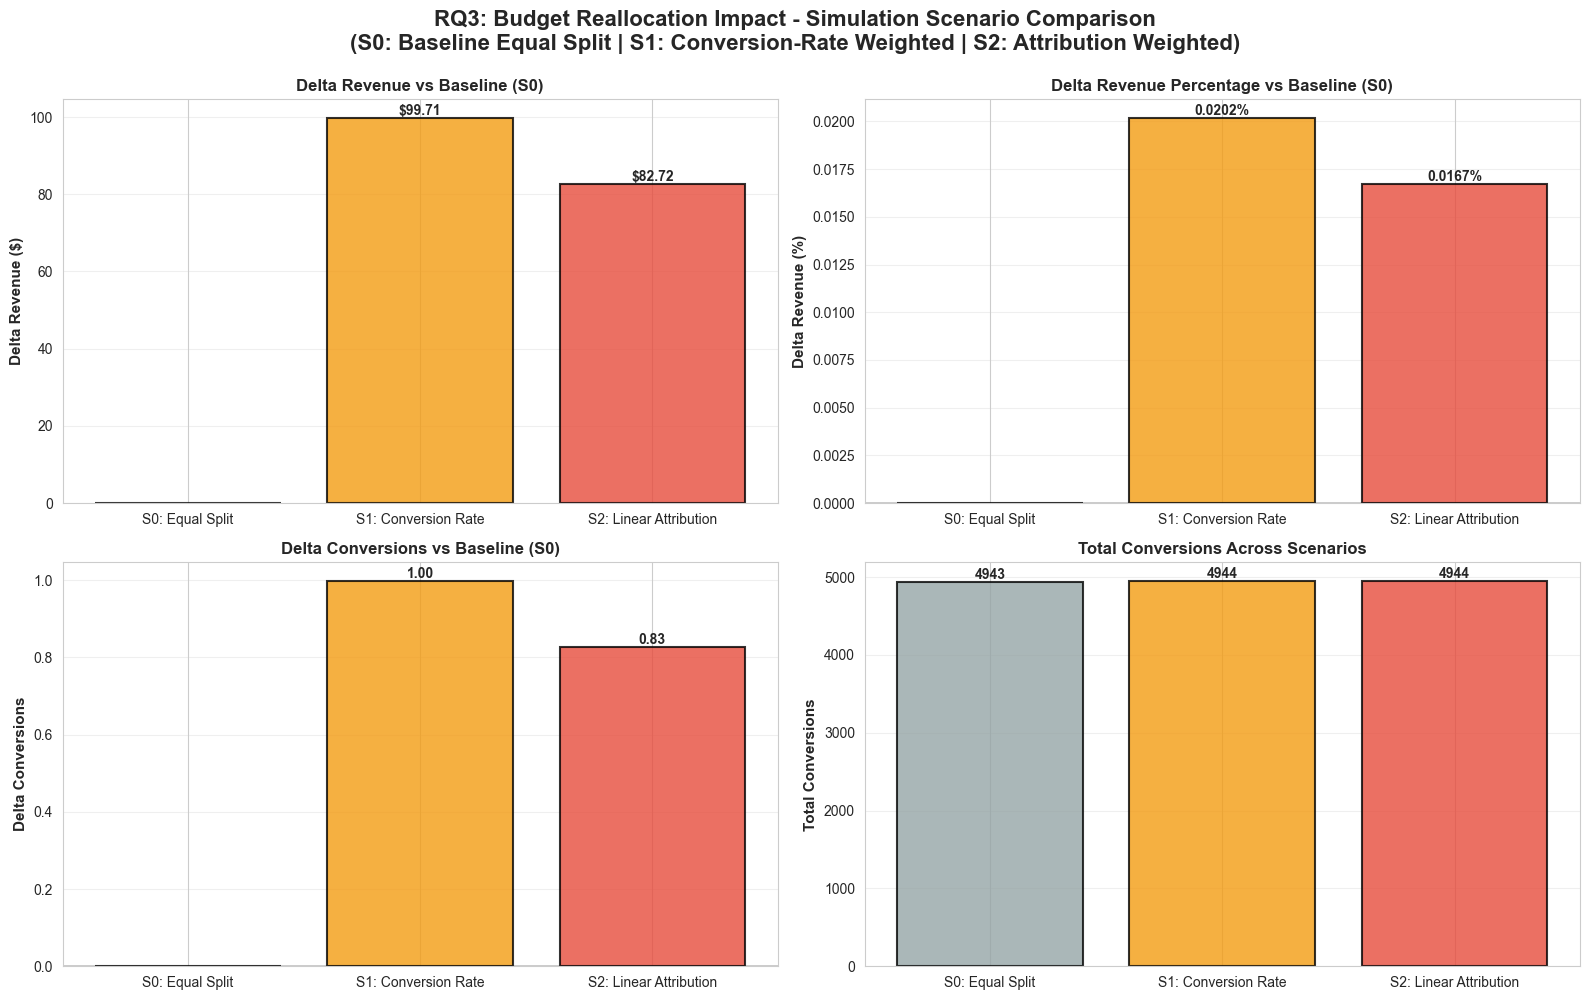

Chart 6 saved: Simulation Scenario Results


In [63]:
# Create a comprehensive RQ3 visualization with multiple metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Delta Revenue
ax1 = axes[0, 0]
scenarios = df_simulation['scenario'].str.replace('S0_equal', 'S0: Equal Split')\
                                     .str.replace('S1_conversion_rate', 'S1: Conversion Rate')\
                                     .str.replace('S2_linear_attribution', 'S2: Linear Attribution')
colors_scenarios = ['#95a5a6', '#f39c12', '#e74c3c']
bars1 = ax1.bar(scenarios, df_simulation['delta_revenue'], color=colors_scenarios, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Delta Revenue ($)', fontsize=11, fontweight='bold')
ax1.set_title('Delta Revenue vs Baseline (S0)', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for bar in bars1:
    height = bar.get_height()
    if height != 0:
        ax1.text(bar.get_x() + bar.get_width()/2., height, f'${height:.2f}', 
                ha='center', va='bottom' if height > 0 else 'top', fontsize=10, fontweight='bold')

# 2. Delta Revenue Percentage
ax2 = axes[0, 1]
bars2 = ax2.bar(scenarios, df_simulation['delta_rev_pct'], color=colors_scenarios, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Delta Revenue (%)', fontsize=11, fontweight='bold')
ax2.set_title('Delta Revenue Percentage vs Baseline (S0)', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=0, color='black', linewidth=1)
for bar in bars2:
    height = bar.get_height()
    if height != 0:
        ax2.text(bar.get_x() + bar.get_width()/2., height, f'{height:.4f}%', 
                ha='center', va='bottom' if height > 0 else 'top', fontsize=10, fontweight='bold')

# 3. Delta Conversions
ax3 = axes[1, 0]
bars3 = ax3.bar(scenarios, df_simulation['delta_conversions'], color=colors_scenarios, alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Delta Conversions', fontsize=11, fontweight='bold')
ax3.set_title('Delta Conversions vs Baseline (S0)', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
ax3.axhline(y=0, color='black', linewidth=1)
for bar in bars3:
    height = bar.get_height()
    if height != 0:
        ax3.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}', 
                ha='center', va='bottom' if height > 0 else 'top', fontsize=10, fontweight='bold')

# 4. Total Conversions
ax4 = axes[1, 1]
bars4 = ax4.bar(scenarios, df_simulation['conversions'], color=colors_scenarios, alpha=0.8, edgecolor='black', linewidth=1.5)
ax4.set_ylabel('Total Conversions', fontsize=11, fontweight='bold')
ax4.set_title('Total Conversions Across Scenarios', fontsize=12, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
for bar in bars4:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height, f'{height:.0f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Main title
fig.suptitle('RQ3: Budget Reallocation Impact - Simulation Scenario Comparison\n(S0: Baseline Equal Split | S1: Conversion-Rate Weighted | S2: Attribution Weighted)', 
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig(rq3_simulation + 'chart_06_simulation_scenario_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart 6 saved: Simulation Scenario Results")

## 9. Export Visualizations & Summary

In [64]:
import os

# Create summary report
summary_report = """
# MULTI-CHANNEL ATTRIBUTION ANALYSIS - VISUALIZATION SUMMARY

## Hình 1: Attribution Share by Method (So sánh 3 phương pháp)

**Loại biểu đồ:** Grouped Bar Chart (Biểu đồ cột nhóm)

### Mục đích
So sánh cách ba mô hình Attribution phân bổ credit cho từng marketing channel.

### Các mô hình được sử dụng

- **First-Touch Attribution:** Toàn bộ credit được gán cho điểm chạm đầu tiên khi khách hàng lần đầu tiếp xúc với thương hiệu.
- **Last-Touch Attribution:** Toàn bộ credit được gán cho điểm chạm cuối cùng trước khi khách hàng chuyển đổi.
- **Linear Attribution:** Credit được chia đều cho tất cả các điểm chạm trong hành trình khách hàng.

### Ý nghĩa
Biểu đồ cho thấy sự khác biệt trong cách mỗi phương pháp đánh giá mức độ đóng góp của từng channel đối với conversion.

---

## Hình 2: Channel Conversion Rate (Tỷ lệ chuyển đổi của từng Channel)

**Loại biểu đồ:** Horizontal Bar Chart (Biểu đồ cột ngang)

### Mục đích
Đánh giá hiệu quả chuyển đổi của từng marketing channel.

### Hiển thị

- Tỷ lệ chuyển đổi (%) của từng channel.
- Các channel được sắp xếp từ thấp đến cao.

### Ý nghĩa
Giúp xác định channel nào có khả năng chuyển đổi khách hàng tốt nhất và channel nào hoạt động kém hiệu quả hơn.

---

## Hình 3: Logit-Adjusted Attribution Share (Kết quả hồi quy Logistic)

**Loại biểu đồ:** Bar Chart (Biểu đồ cột)

### Mục đích
Đánh giá mức độ ảnh hưởng của từng channel bằng mô hình Machine Learning.

### Phương pháp

Sử dụng mô hình **Logistic Regression** để:

- Phân tích dữ liệu lịch sử.
- Ước lượng mức độ ảnh hưởng của từng channel đến xác suất chuyển đổi.
- Điều chỉnh Attribution Share dựa trên sức ảnh hưởng thực tế.

### Ý nghĩa
Các channel có Attribution Share cao hơn được xem là có ảnh hưởng mạnh hơn đến conversion.

---

## Hình 4: Model Comparison (Biểu đồ quan trọng nhất của RQ2)

**Loại biểu đồ:** Heatmap (Bản đồ nhiệt)

### Mục đích
So sánh kết quả Attribution giữa năm mô hình khác nhau.

### Các mô hình được so sánh

1. First-Touch
2. Last-Touch
3. Linear
4. Logistic Regression (Logit)
5. Markov Chain

### Quan sát chính

#### Display Ads

- Được đánh giá rất cao bởi các mô hình hiện đại.
- Logit Attribution: 21.99%
- Markov Attribution: 76.06%

Điều này cho thấy Display Ads có vai trò quan trọng trong quá trình dẫn dắt khách hàng đến conversion.

#### Social Media

- Attribution Share tương đối ổn định trên tất cả các mô hình.
- Dao động khoảng 16%–17%.

Điều này cho thấy Social Media có mức đóng góp nhất quán và ít gây tranh cãi giữa các phương pháp đánh giá.

#### Linear Attribution

- Các giá trị phân bổ nằm ở mức trung bình.
- Không quá thiên vị điểm chạm đầu tiên hay cuối cùng.
- Được xem là phương pháp công bằng nhất.

### Kết luận cho RQ2

- **Linear Attribution** được khuyến nghị khi cần sự cân bằng và dễ giải thích.
- **Logit** hoặc **Markov** phù hợp hơn khi doanh nghiệp muốn tối đa hóa độ chính xác trong phân tích hành vi khách hàng.

---

## Hình 5: Markov Removal Effect (Tác động khi loại bỏ Channel)

**Loại biểu đồ:** Horizontal Bar Chart (Biểu đồ cột ngang)

### Mục đích

Đo lường mức thay đổi của tỷ lệ chuyển đổi nếu một channel bị loại khỏi customer journey.

### Câu hỏi được trả lời

"Nếu channel này không tồn tại thì conversion sẽ thay đổi như thế nào?"

### Kết quả

#### Display Ads

- Removal Effect: +0.0535%

Nếu loại bỏ Display Ads, tỷ lệ chuyển đổi sẽ giảm đáng kể.

#### Referral

- Removal Effect: +0.0168%

Referral cũng đóng vai trò quan trọng trong việc hỗ trợ chuyển đổi.

#### Social Media, Direct Traffic, Email và Search Ads

- Giá trị âm hoặc gần bằng 0.

Điều này cho thấy việc loại bỏ các channel này không tạo ra sự thay đổi đáng kể đối với conversion rate.

### Kết luận

Display Ads và Referral là hai channel có giá trị hỗ trợ lớn nhất trong customer journey theo góc nhìn Markov Chain.

---

# Hình 6: Simulation Scenario Results (RQ3)

Hình 6 là một Dashboard mô phỏng nhằm so sánh ba chiến lược phân bổ ngân sách marketing khác nhau.

## Ba kịch bản được đánh giá

| Kịch bản | Tên | Mô tả |
|----------|------|--------|
| S0 | Equal Split | Chia đều ngân sách cho 6 channel, mỗi channel nhận 16.67% |
| S1 | Conversion-Rate Weighted | Phân bổ ngân sách theo tỷ lệ chuyển đổi của từng channel |
| S2 | Linear Attribution Weighted | Phân bổ ngân sách theo kết quả của mô hình Linear Attribution |

---

## Ô 1: Delta Revenue vs Baseline (S0)

### Kết quả

| Scenario | Delta Revenue |
|-----------|---------------|
| S0 | $0.00 |
| S1 | +$99.71 |
| S2 | +$82.72 |

### Giải thích

- S1 tạo ra mức tăng doanh thu cao nhất.
- S2 cũng tạo ra cải thiện nhưng thấp hơn S1.

Nguyên nhân là S1 tập trung ngân sách nhiều hơn vào các channel có conversion rate cao như Email và Referral.

---

## Ô 2: Delta Revenue Percentage vs Baseline (S0)

### Kết quả

| Scenario | Delta Revenue (%) |
|-----------|------------------|
| S0 | 0.0000% |
| S1 | +0.0202% |
| S2 | +0.0167% |

### Giải thích

Cả S1 và S2 đều cải thiện doanh thu nhưng mức tăng tương đối nhỏ.

Nguyên nhân là:

- Các channel trong bộ dữ liệu có hiệu suất khá tương đồng.
- Việc thay đổi phân bổ ngân sách chỉ tạo ra lợi ích biên (marginal gain).

Ví dụ:

- Doanh thu cơ sở khoảng $494,000.
- Tăng 0.0202% tương ứng khoảng $99.71.

---

## Ô 3: Delta Conversions vs Baseline (S0)

### Kết quả

| Scenario | Delta Conversions |
|-----------|------------------|
| S0 | 0 |
| S1 | +0.997 |
| S2 | +0.827 |

### Giải thích

- S1 tạo thêm khoảng 1 conversion.
- S2 tạo thêm khoảng 0.8 conversion.

Mặc dù mức tăng không lớn nhưng vẫn mang lại lợi ích tài chính tích cực khi áp dụng trên quy mô lớn.

---

## Ô 4: Total Conversions Across Scenarios

### Kết quả

| Scenario | Total Conversions |
|-----------|------------------|
| S0 | 4,943 |
| S1 | 4,944 |
| S2 | 4,944 |

### Giải thích

Tổng số conversion giữa ba kịch bản gần như tương đương nhau.

Điều này cho thấy:

- Không có chiến lược nào tạo ra sự đột phá lớn.
- Các thay đổi chủ yếu là tối ưu hóa biên.
- Hiệu quả của việc tái phân bổ ngân sách tương đối hạn chế trong bộ dữ liệu hiện tại.

---

# Ý nghĩa Quản trị của Hình 6

Hình 6 là phần quan trọng nhất của toàn bộ dự án vì nó chuyển các kết quả phân tích học thuật thành giá trị kinh doanh cụ thể.

Thay vì chỉ xác định channel nào quan trọng, hình này trả lời trực tiếp câu hỏi:

> "Nếu thay đổi cách phân bổ ngân sách theo mô hình đề xuất, doanh nghiệp sẽ kiếm thêm bao nhiêu tiền?"

## 1. Hỗ trợ xây dựng chiến lược phân bổ ngân sách

Hình 6 cung cấp sẵn các kịch bản thay thế để so sánh với phương pháp hiện tại.

### S1: Conversion-Rate Weighted

Nguyên tắc:

> Đầu tư nhiều hơn vào những channel có khả năng tạo conversion cao nhất.

Ví dụ:

- Email
- Referral

### S2: Linear Attribution Weighted

Nguyên tắc:

> Phân bổ ngân sách dựa trên mức đóng góp của các điểm chạm trong customer journey.

Ví dụ:

- Display Ads
- Direct Traffic

---

## 2. Định lượng hóa lợi ích tài chính (ROI)

Hình 6 giúp chuyển các kết quả Data Science thành giá trị tài chính cụ thể.

Ví dụ:

- S1 tạo thêm khoảng $99.71 doanh thu.
- Tương đương mức tăng khoảng 0.02%.

Nhờ đó:

- Marketing Team có cơ sở ra quyết định.
- Ban Giám Đốc có căn cứ để phê duyệt chiến lược ngân sách mới.

---

## 3. Đánh giá mức độ rủi ro

Mặc dù S1 và S2 cho kết quả tốt hơn S0, mức cải thiện vẫn rất nhỏ.

### Quan sát

- Doanh thu chỉ tăng khoảng 0.02%.
- Tổng conversion chỉ tăng khoảng 1 khách hàng.

### Ý nghĩa

Điều này giúp doanh nghiệp:

- Tránh kỳ vọng quá mức.
- Hiểu rằng tối ưu hóa marketing attribution thường là bài toán tối ưu biên.
- Thực hiện thử nghiệm trên quy mô nhỏ trước khi áp dụng rộng rãi.

---

# Kết luận

Hình 6 là công cụ hỗ trợ ra quyết định quan trọng nhất trong nghiên cứu.

Nó giúp thuyết phục nhà quản lý bằng cách trả lời trực tiếp:

> "Nếu áp dụng các kết quả từ Data Science vào việc phân bổ ngân sách marketing, doanh nghiệp sẽ thu được thêm bao nhiêu doanh thu so với cách phân bổ truyền thống?"

Đồng thời, hình cũng cung cấp một góc nhìn thực tế về mức độ cải thiện có thể đạt được, giúp doanh nghiệp cân bằng giữa kỳ vọng lợi nhuận và rủi ro triển khai.

"""

# Save summary report
report_path = base_path + 'VISUALIZATION_SUMMARY.md'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(summary_report)

print("✓ Summary report saved to:", report_path)
print("\n" + "="*80)
print("ALL VISUALIZATIONS COMPLETED SUCCESSFULLY!")
print("="*80)
print(f"\n📊 Total charts generated: 6")
print(f"📁 Output directory: {base_path}")
print(f"\n📋 Chart Files:")
print(f"   1. chart_01_attribution_share_by_method.png")
print(f"   2. chart_02_channel_conversion_rate.png")
print(f"   3. chart_03_logit_adjusted_share.png")
print(f"   4. chart_04_model_comparison_heatmap.png")
print(f"   5. chart_05_markov_removal_effect.png")
print(f"   6. chart_06_simulation_scenario_results.png")
print(f"\n📄 Summary Report: VISUALIZATION_SUMMARY.md")

✓ Summary report saved to: ./outputs/VISUALIZATION_SUMMARY.md

ALL VISUALIZATIONS COMPLETED SUCCESSFULLY!

📊 Total charts generated: 6
📁 Output directory: ./outputs/

📋 Chart Files:
   1. chart_01_attribution_share_by_method.png
   2. chart_02_channel_conversion_rate.png
   3. chart_03_logit_adjusted_share.png
   4. chart_04_model_comparison_heatmap.png
   5. chart_05_markov_removal_effect.png
   6. chart_06_simulation_scenario_results.png

📄 Summary Report: VISUALIZATION_SUMMARY.md
